# Exercises for Chapter 19, Causal inference using regression on the treatment variable

In [51]:
import os
import sys

import bambi
import numpy
import pandas

from matplotlib import pyplot

sys.path.append(os.path.abspath("/home/bgawalt/ros"))
import bg_ros

In [52]:
prng_builder = bg_ros.PRNGBuilder('Exercises for Chapter 19, Causal inference using regression on the treatment variable')

## 19.4, Pre-test and post-test

> 100 students are given a pre-test, then a treatment or control is randomly
> assigned to each, then they get a post-test.  Given the following regression
> model:
>
> $$\text{post\_test} = a + b \cdot \text{pre\_test} + \theta \cdot z + \text{error},$$
>
> where $z = 1$ for treated units and 0 for controls.  Further suppose that
> `pre_test` has mean 40 and standard deviation 15.  Suppose $b = 0.7$ and
> $\theta = 10$ and the mean for `post_test` is 50 for the students in the
> control group. Further suppose that the residual standard deviation of the 
> regression is 10.
>
> (a) Determine a.
>
> (b) What is the standard deviation of the post-test scores for the students in
>     the control group?
>
> (c) What are the mean and standard deviation of the post-test scores in the
>     treatment group?

In [53]:
# E[post] = a + b E[pre]
a = 50 - (0.7 * 40)
sd_y0 = 0.7 * 15 + 10
mu_y1 = a + (0.7 * 40) + 10
print(f'a = {a:0.2f}')
print(f'sd_y0 = {sd_y0:0.2f}')
print(f'mu_y1 = {mu_y1:0.2f}')

a = 22.00
sd_y0 = 20.50
mu_y1 = 60.00


## 19.6, Sketching the regression model for causal inference

> Assume that linear regression is appropriate for the regression of an outcome,
> $y$, on treatment indicator, $z$, and a single confounding covariate, $x$.
> With pen on paper, sketch hypothetical data (plotting $y$ versus $x$, with
> treated and control units indicated by circles and dots, respectively) and
> regression lines (for treatment and control group) that represent each of the
> following situations:
>
> (a) No treatment effect,
> 
> (b) Constant treatment effect,
>
> (c) Treatment effect increasing with $x$.

In [54]:
rng = prng_builder.new('19.6, Sketching the regression model for causal inference')

In [55]:
def fake_series(
    rng: numpy.random.Generator,
    constant_effect: float = 0,
    covariate_effect: float = 0
) -> (numpy.ndarray, numpy.ndarray):
    n = 40
    xs = rng.uniform(low=0, high=10, size=n)
    ys = 20 + constant_effect + (-3 + covariate_effect) * xs + rng.normal(scale=2, size=n)
    return (xs, ys)

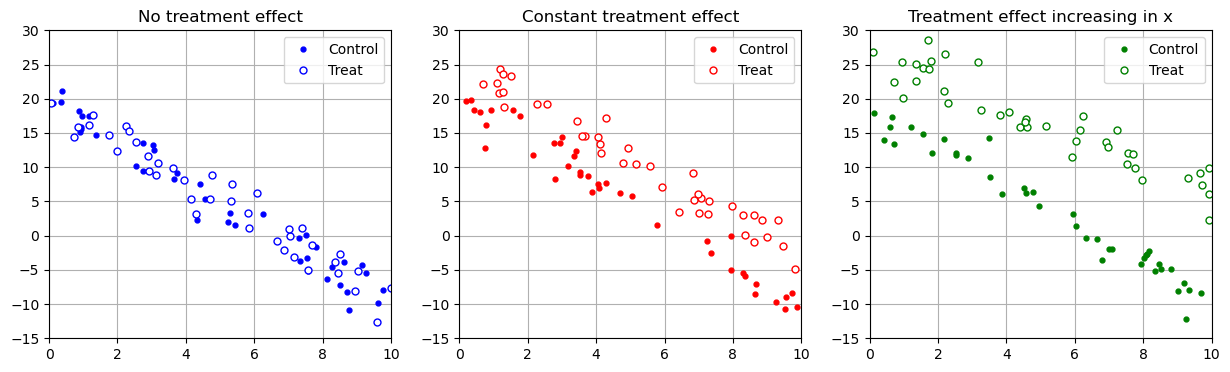

In [56]:
fig, axs = pyplot.subplots(nrows=1, ncols=3, figsize=(15, 4))

x_c, y_c = fake_series(rng)
x_t, y_t = fake_series(rng)
ax = axs[0]
ax.set_title('No treatment effect')
color = 'b'

ax.plot(x_c, y_c, mec=color, mfc=color, linewidth=0, marker='.', markersize=7, label='Control')
ax.plot(x_t, y_t, mec=color, mfc='w', linewidth=0, marker='o', markersize=5, label='Treat')
ax.grid()
ax.set_axisbelow(True)
ax.set_ylim(-15, 30)
ax.set_xlim(0, 10)
ax.legend()

x_c, y_c = fake_series(rng)
x_t, y_t = fake_series(rng, constant_effect=6)
ax = axs[1]
ax.set_title('Constant treatment effect')
color = 'r'

ax.plot(x_c, y_c, mec=color, mfc=color, linewidth=0, marker='.', markersize=7, label='Control')
ax.plot(x_t, y_t, mec=color, mfc='w', linewidth=0, marker='o', markersize=5, label='Treat')
ax.grid()
ax.set_axisbelow(True)
ax.set_ylim(-15, 30)
ax.set_xlim(0, 10)
ax.legend()

x_c, y_c = fake_series(rng)
x_t, y_t = fake_series(rng, constant_effect=6, covariate_effect=1)
ax = axs[2]
ax.set_title('Treatment effect increasing in x')
color = 'g'

ax.plot(x_c, y_c, mec=color, mfc=color, linewidth=0, marker='.', markersize=7, label='Control')
ax.plot(x_t, y_t, mec=color, mfc='w', linewidth=0, marker='o', markersize=5, label='Treat')
ax.grid()
ax.set_axisbelow(True)
ax.set_ylim(-15, 30)
ax.set_xlim(0, 10)
ax.legend()

## 19.7, Linearity assumptions and causal inference

> Consider a study with an outcome, $y$, a treatment indicator, $z$, and a
> single confounding covariate, $x$. Draw a scatterplot of treatment and control
> observations that demonstrates each of the following:
>
> (a) A scenario where the difference in means estimate would not capture the
>     true treatment effect but a regression of $y$ on $x$ and $z$ would yield
>     the correct estimate.
>
> (b) A scenario where a linear regression would yield the wrong estimate but a
>     nonlinear regression would yield the correct estimate.

In [87]:
rng = prng_builder.new('19.7, Linearity assumptions and causal inference')

### 19.7(a)

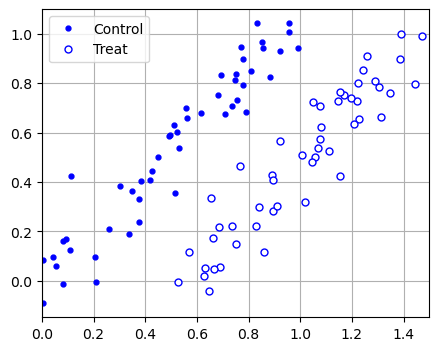

In [88]:
xs_c = rng.uniform(low=0, high=1, size=50)
ys_c = xs_c + rng.normal(scale=0.1, size=50)
xs_t = rng.uniform(low=0.5, high=1.5, size=50)
ys_t = xs_t - 0.5 + rng.normal(scale=0.1, size=50)

fig = pyplot.figure(figsize=(5, 4))
ax = fig.gca()
color = 'b'

ax.plot(xs_c, ys_c, mec=color, mfc=color, linewidth=0, marker='.', markersize=7, label='Control')
ax.plot(xs_t, ys_t, mec=color, mfc='w', linewidth=0, marker='o', markersize=5, label='Treat')
ax.grid()
ax.set_axisbelow(True)
ax.set_xlim(0, 1.5)
ax.legend()


In [89]:
delta_y = numpy.mean(ys_t) - numpy.mean(ys_c)
print(f'Diff. in means: {delta_y:0.2f}')

Diff. in means: -0.05


In [90]:
xs = [xi for xi in xs_c] + [xi for xi in xs_t]
ys = [yi for yi in ys_c] + [yi for yi in ys_t]
zs = numpy.array([0 for _ in range(50)] + [1 for _ in range(50)])
df_7a = pandas.DataFrame(data={'x': xs, 'y': ys, 'z': zs})

In [91]:
model_7a = bambi.Model('y ~ x + z', df_7a)
model_7a_fit = model_7a.fit()
print(bg_ros.bambi_markdown(model_7a_fit, ['x', 'z']))

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, x, z]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 8 seconds.


Coef.     | Mean   | s.e.
--------- | ------ | ------
sigma     | 0.10 | 0.01
Intercept | -0.00 | 0.03
x         | 1.06 | 0.04
z         | -0.57 | 0.03



### 19.7(b)

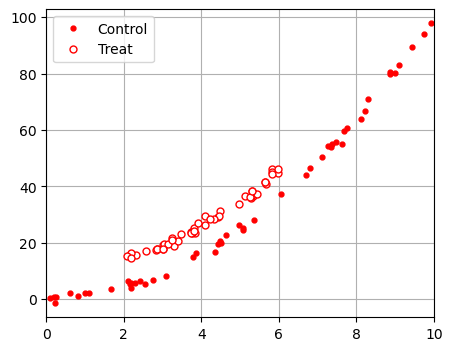

In [92]:
xs_c = rng.uniform(low=0, high=10, size=50)
ys_c = numpy.pow(xs_c, 2) + rng.normal(size=50)
xs_t = rng.uniform(low=2, high=6, size=50)
ys_t = 10 + numpy.pow(xs_t, 2) + rng.normal(size=50)

fig = pyplot.figure(figsize=(5, 4))
ax = fig.gca()
color = 'r'

ax.plot(xs_c, ys_c, mec=color, mfc=color, linewidth=0, marker='.', markersize=7, label='Control')
ax.plot(xs_t, ys_t, mec=color, mfc='w', linewidth=0, marker='o', markersize=5, label='Treat')
ax.grid()
ax.set_axisbelow(True)
ax.set_xlim(0, 10)
ax.legend()

In [93]:
df_7b = pandas.DataFrame(data={
    'y': [yi for yi in ys_c] + [yi for yi in ys_t],
    'x': [xi for xi in xs_c] + [xi for xi in xs_t],
    'x2': [xi * xi for xi in xs_c] + [xi * xi for xi in xs_t],
    'z': [0 for _ in range(50)] + [1 for _ in range(50)],
})

In [94]:
model_7b_bad = bambi.Model('y ~ x + z', df_7b)
model_7b_bad_fit = model_7b_bad.fit()
print(bg_ros.bambi_markdown(model_7b_bad_fit, ['x', 'z']))

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, x, z]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 8 seconds.


Coef.     | Mean   | s.e.
--------- | ------ | ------
sigma     | 5.92 | 0.42
Intercept | -13.29 | 1.55
x         | 9.49 | 0.26
z         | 2.51 | 1.21



In [95]:
model_7b_good = bambi.Model('y ~ x + x2 + z', df_7b)
model_7b_good_fit = model_7b_good.fit()
print(bg_ros.bambi_markdown(model_7b_good_fit, ['x', 'x2', 'z']))

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, x, x2, z]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 9 seconds.


Coef.     | Mean   | s.e.
--------- | ------ | ------
sigma     | 1.14 | 0.09
Intercept | 0.76 | 0.41
x         | -0.26 | 0.21
x2        | 1.02 | 0.02
z         | 9.81 | 0.28

